# Implementação de um Autoencoder (AEs)

Disciplina: Métodos e Modelos Avançados em Ciência de Dados

Especialização em Ciência de Dados - Universidade Tecnologica Federal do Paraná

Aula 05: AEs

Linguagem de Programação: **Python**

by: Rafael G. Mantovani
---

In [ ]:
# imports necessários para executar o exemplo
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [ ]:
# ===============================
# 1. Carregando o dataset digits e preprocessando os dados
# ===============================
digits = load_digits()
X = digits.data
scaler = MinMaxScaler()
X = scaler.fit_transform(X)  # normalizando em [0,1]

n_samples, n_features = X.shape
n_hidden = 32  # quantidade de features latentes

In [ ]:
# ===============================
# 2. Inicializando os parametros
# ===============================
rng = np.random.default_rng(42)
W1 = rng.normal(0, 0.1, (n_features, n_hidden))
b1 = np.zeros((1, n_hidden))
W2 = rng.normal(0, 0.1, (n_hidden, n_features))
b2 = np.zeros((1, n_features))

In [ ]:
# ===============================
# 3. Função do Activação
# ===============================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

In [ ]:
# ===============================
# 4. Forward e backward
# ===============================
def forward(x):
    z1 = x @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1, a1, z2, a2

# Calculo do Erro
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


In [ ]:
# ===============================
# 5. Laço de Treinamento (Denoising Autoencoder)
# ===============================
lr = 0.1
epochs = 2000
noise_factor = 0.2  # quanto de ruído é inserido na camada

for epoch in range(epochs):
    # Adicionando ruído gaussiano nas entradas (denoising autoenconder)
    noisy_X = X + noise_factor * rng.normal(0, 1, X.shape)
    noisy_X = np.clip(noisy_X, 0, 1)  # keep in [0,1]

    # Forward pass
    z1, a1, z2, a2 = forward(noisy_X)
    loss = compute_loss(X, a2)

    # Backpropagation
    d_loss = 2 * (a2 - X) / n_samples
    d_z2 = d_loss * sigmoid_derivative(z2)
    d_W2 = a1.T @ d_z2
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)

    d_a1 = d_z2 @ W2.T
    d_z1 = d_a1 * sigmoid_derivative(z1)
    d_W1 = noisy_X.T @ d_z1
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)

    # Atualização dos pesos
    W1 -= lr * d_W1
    b1 -= lr * d_b1
    W2 -= lr * d_W2
    b2 -= lr * d_b2

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.6f}")

Epoch 10/2000 | Loss: 0.069983
Epoch 20/2000 | Loss: 0.069546
Epoch 30/2000 | Loss: 0.069056
Epoch 40/2000 | Loss: 0.068542
Epoch 50/2000 | Loss: 0.068000
Epoch 60/2000 | Loss: 0.067386
Epoch 70/2000 | Loss: 0.066790
Epoch 80/2000 | Loss: 0.066129
Epoch 90/2000 | Loss: 0.065430
Epoch 100/2000 | Loss: 0.064727
Epoch 110/2000 | Loss: 0.063987
Epoch 120/2000 | Loss: 0.063251
Epoch 130/2000 | Loss: 0.062455
Epoch 140/2000 | Loss: 0.061705
Epoch 150/2000 | Loss: 0.060962
Epoch 160/2000 | Loss: 0.060181
Epoch 170/2000 | Loss: 0.059364
Epoch 180/2000 | Loss: 0.058593
Epoch 190/2000 | Loss: 0.057786
Epoch 200/2000 | Loss: 0.057055
Epoch 210/2000 | Loss: 0.056271
Epoch 220/2000 | Loss: 0.055561
Epoch 230/2000 | Loss: 0.054785
Epoch 240/2000 | Loss: 0.054148
Epoch 250/2000 | Loss: 0.053457
Epoch 260/2000 | Loss: 0.052791
Epoch 270/2000 | Loss: 0.052203
Epoch 280/2000 | Loss: 0.051546
Epoch 290/2000 | Loss: 0.050899
Epoch 300/2000 | Loss: 0.050410
Epoch 310/2000 | Loss: 0.049862
Epoch 320/2000 | 

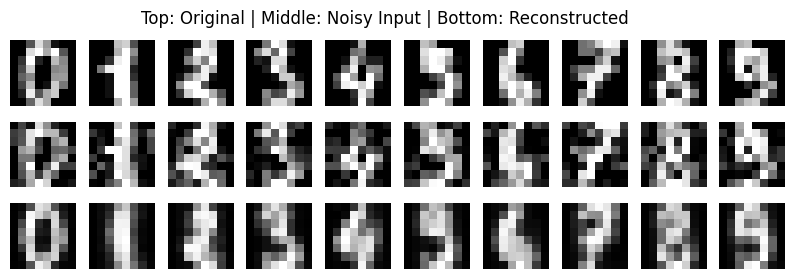

In [ ]:
# ===============================
# 6. Visualizar as reconstruções
# ===============================
n = 10
_, _, _, recon = forward(X[:n])

plt.figure(figsize=(10, 3))
for i in range(n):
    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(X[i].reshape(8, 8), cmap="gray")
    plt.axis("off")
    # Noisy input
    noisy = np.clip(X[i] + noise_factor * rng.normal(0, 1, X[i].shape), 0, 1)
    plt.subplot(3, n, n + i + 1)
    plt.imshow(noisy.reshape(8, 8), cmap="gray")
    plt.axis("off")
    # Reconstructed
    plt.subplot(3, n, 2 * n + i + 1)
    plt.imshow(recon[i].reshape(8, 8), cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Original | Middle: Noisy Input | Bottom: Reconstructed", fontsize=12)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
y = digits.target

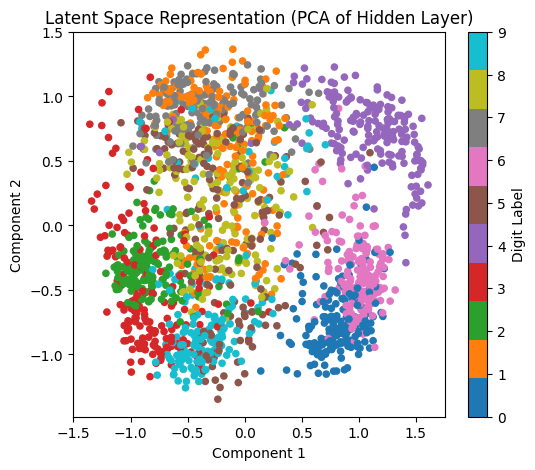

In [ ]:
# ===============================
# 7. Latent space visualization (via PCA)
# ===============================
_, hidden, _, _ = forward(X)
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(hidden)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y, cmap="tab10", s=20)
plt.colorbar(scatter, label="Digit Label")
plt.title("Latent Space Representation (PCA of Hidden Layer)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [ ]:
import umap

Applying UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


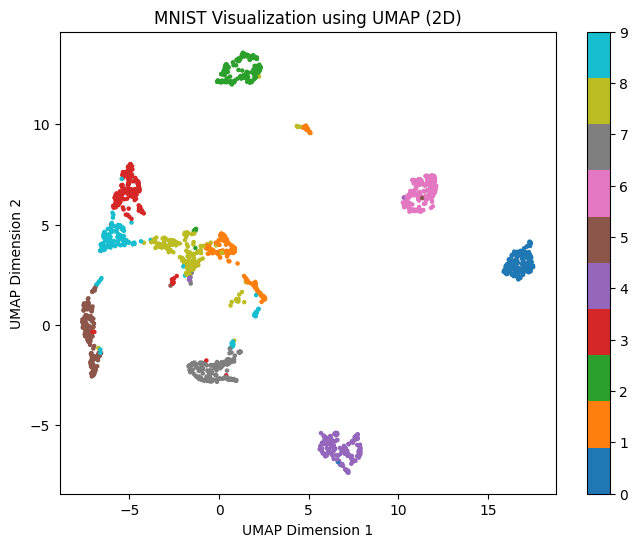

In [ ]:
# ===============================
# 8. Latent space visualization (via UMAP)
# ===============================

# _, hidden, _, _ = forward(X)

# 3. UMAP visualization
print("Applying UMAP...")
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap = reducer.fit_transform(hidden)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title("MNIST Visualization using UMAP (2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()